In [4]:
from opensearchpy import OpenSearch
import sys, os
from opensearchpy.helpers import bulk

IS_AUTH = True
HOST = 'localhost'

# Get the current working directory of the notebook
current_dir = os.getcwd()

DATA_DIR = os.path.abspath(os.path.join(current_dir, '../../0. DATA'))

# Construct the path to the directory levels up
module_paths = [os.path.abspath(os.path.join(current_dir, '../../')),] 

# Add the module path to sys.path if it's not already there
for module_path in module_paths:
    if module_path not in sys.path:
        sys.path.append(module_path)

try:
    import helpers as hp
except ImportError as e:
    raise ImportError(f"Error importing modules: {e}")

if IS_AUTH:
    # Initialize the OpenSearch client
    client = OpenSearch(
        hosts=[{'host': HOST, 'port': 9200}],
        http_auth=('admin', 'Developer@123'),  # Replace with your credentials
        use_ssl=True,
        verify_certs=False,
        ssl_show_warn=False
    )
else:
    # Initialize the OpenSearch client without authentication
    client = OpenSearch(
        hosts=[{'host': HOST, 'port': 9200}],
        use_ssl=False,
        verify_certs=False,
        ssl_assert_hostname = False,
        ssl_show_warn=False
    )

# Create vector index with mapping
# l2 means distance metrics is Euclidean distance
hotels_mapping = {
    "settings": {
        "index.knn": True
    },
    "mappings": {
        "properties": {
            "location": {
                "type": "knn_vector",
                "dimension": 2,
                "space_type": "l2"
            }
        }
    }
}

# Create the index
index_name = "hotels-index"
if client.indices.exists(index=index_name):
    client.indices.delete(index=index_name)

client.indices.create(index=index_name, body=hotels_mapping)
print(f"Created index: {index_name}")

# Add data to your index
hotels_data = [
    {"_index": "hotels-index", "_id": "1", "_source": {"location": [5.2, 4.4]}},
    {"_index": "hotels-index", "_id": "2", "_source": {"location": [5.2, 3.9]}},
    {"_index": "hotels-index", "_id": "3", "_source": {"location": [4.9, 3.4]}},
    {"_index": "hotels-index", "_id": "4", "_source": {"location": [4.2, 4.6]}},
    {"_index": "hotels-index", "_id": "5", "_source": {"location": [3.3, 4.5]}}
]

# Bulk insert the data
success, failed = bulk(client=client, actions=hotels_data)
print(f"Successfully indexed: {success} documents")

# Refresh the index to make documents available for search immediately
client.indices.refresh(index=index_name)
print("Index refreshed")

# Search your data using KNN
search_query = {
    "size": 3,
    "query": {
        "knn": {
            "location": {
                "vector": [5, 4],
                "k": 3
            }
        }
    }
}

# Execute the search
response = client.search(index="hotels-index", body=search_query)

print(f"Found {response['hits']['total']['value']} results:")
for hit in response['hits']['hits']:
    print(f"ID: {hit['_id']}, Score: {hit['_score']}, Location: {hit['_source']['location']}")

Created index: hotels-index
Successfully indexed: 5 documents
Index refreshed
Found 3 results:
ID: 2, Score: 0.952381, Location: [5.2, 3.9]
ID: 1, Score: 0.8333333, Location: [5.2, 4.4]
ID: 3, Score: 0.72992706, Location: [4.9, 3.4]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


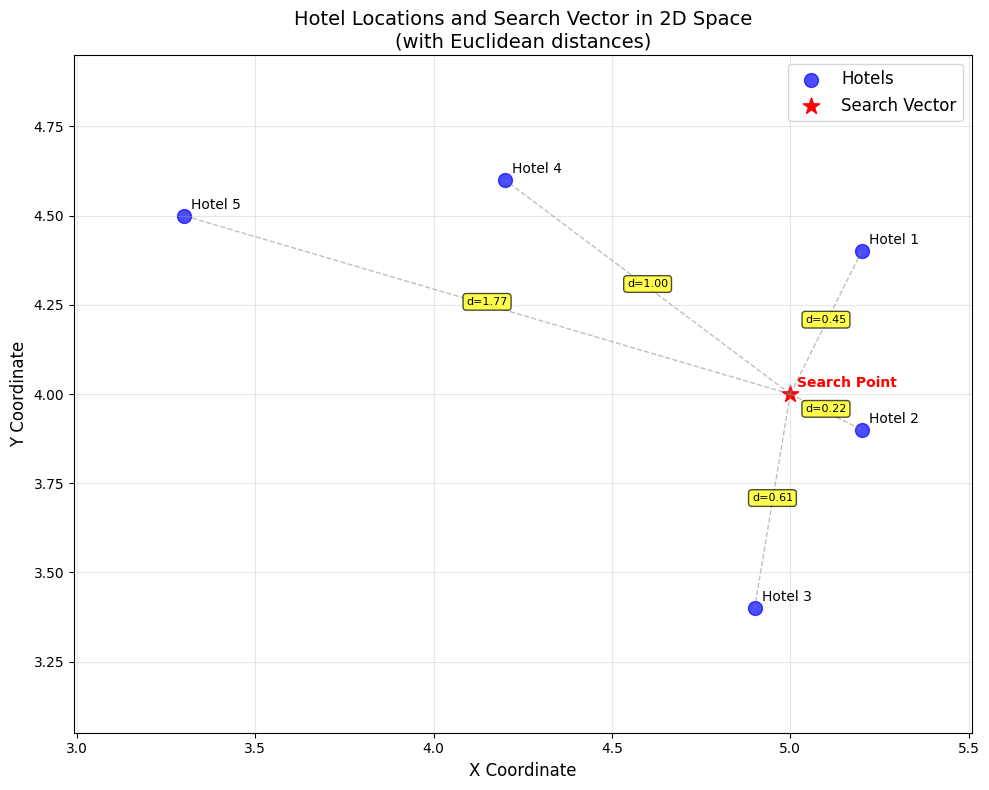


Search Results (ordered by similarity):
1. Hotel 2: Location [5.2, 3.9], Score: 0.9524, Distance: 0.22
2. Hotel 1: Location [5.2, 4.4], Score: 0.8333, Distance: 0.45
3. Hotel 3: Location [4.9, 3.4], Score: 0.7299, Distance: 0.61


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Extract hotel locations and search vector
hotel_locations = [
    [5.2, 4.4],  # Hotel 1
    [5.2, 3.9],  # Hotel 2  
    [4.9, 3.4],  # Hotel 3
    [4.2, 4.6],  # Hotel 4
    [3.3, 4.5]   # Hotel 5
]

search_vector = [5, 4]

# Convert to numpy arrays for easier plotting
hotels = np.array(hotel_locations)
search_point = np.array(search_vector)

# Create the plot
plt.figure(figsize=(10, 8))

# Plot hotel locations
plt.scatter(hotels[:, 0], hotels[:, 1], 
           c='blue', s=100, alpha=0.7, 
           label='Hotels', marker='o')

# Plot search vector
plt.scatter(search_point[0], search_point[1], 
           c='red', s=150, 
           label='Search Vector', marker='*')

# Add hotel labels
for i, (x, y) in enumerate(hotel_locations):
    plt.annotate(f'Hotel {i+1}', (x, y), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=10, ha='left')

# Add search vector label
plt.annotate('Search Point', search_point, 
            xytext=(5, 5), textcoords='offset points',
            fontsize=10, ha='left', color='red', fontweight='bold')

# Draw lines from search point to each hotel to show distances
for i, hotel in enumerate(hotel_locations):
    plt.plot([search_point[0], hotel[0]], [search_point[1], hotel[1]], 
            'gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Calculate and display Euclidean distance
    distance = np.sqrt((search_point[0] - hotel[0])**2 + (search_point[1] - hotel[1])**2)
    mid_x = (search_point[0] + hotel[0]) / 2
    mid_y = (search_point[1] + hotel[1]) / 2
    plt.annotate(f'd={distance:.2f}', (mid_x, mid_y), 
                fontsize=8, ha='center', 
                bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))

# Customize the plot
plt.xlabel('X Coordinate', fontsize=12)
plt.ylabel('Y Coordinate', fontsize=12)
plt.title('Hotel Locations and Search Vector in 2D Space\n(with Euclidean distances)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Set equal aspect ratio and adjust limits
plt.axis('equal')
plt.xlim(2.5, 6)
plt.ylim(3, 5)

plt.tight_layout()
plt.show()

# Print the search results for reference
print("\nSearch Results (ordered by similarity):")
print("=" * 50)
for i, hit in enumerate(response['hits']['hits']):
    hotel_id = hit['_id']
    location = hit['_source']['location']
    score = hit['_score']
    distance = np.sqrt((search_point[0] - location[0])**2 + (search_point[1] - location[1])**2)
    print(f"{i+1}. Hotel {hotel_id}: Location {location}, Score: {score:.4f}, Distance: {distance:.2f}")

# Preparing vectors
In OpenSearch, you can either bring your own vectors or let OpenSearch generate them automatically from your data. Letting OpenSearch automatically generate your embeddings reduces data preprocessing effort at ingestion and search time.  

**Option 1**: Bring your own raw vectors or generated embeddings  
**Option 2**: Generate embeddings within OpenSearch